# Wybrane Zagadnienia Sztucznej Inteligencji — Zestaw Zaliczeniowy

**WSEI Kraków · semestr letni 2026 · prowadzący: Michał Madejski**

---

## Filozofia tego zestawu

Sześć laboratoriów przeprowadziło Cię od **najprostszego klasyfikatora liniowego** (perceptron) do **sieci pamiętających kontekst** (LSTM). Ten zestaw zaliczeniowy zmusza Cię do **świadomego użycia tych architektur** — każdą na świeżym datasecie z Hugging Face, z porównaniem przed/po.

**Datasety z HF Hub:**
- `sklearn iris` (lokalny w sklearn — używamy do wprowadzenia perceptronu)
- [`zalando-datasets/fashion_mnist`](https://huggingface.co/datasets/zalando-datasets/fashion_mnist) — 70k obrazów 28×28 ubrań (główny image dataset)
- [`uoft-cs/cifar10`](https://huggingface.co/datasets/uoft-cs/cifar10) — 60k obrazów 32×32 RGB
- [`dair-ai/emotion`](https://huggingface.co/datasets/dair-ai/emotion) — 20k tweetów z 6 emocjami

**Reguły:**
1. Każdy lab ma blok: **Teoria → Przykład rozwiązany → Zadanie samodzielne**.
2. Zadania samodzielne **rozszerzają** przykład — ta sama architektura, trudniejszy problem.
3. Cały notebook ma być **uruchamialny od góry do dołu**. Brak ręcznych downloadów.
4. Każde rozwiązanie kończy się **wnioskiem z 2-3 zdań** w komórce Markdown.

**Ocenianie:**
- 50% — poprawność (czy model się uczy, accuracy > baseline)
- 30% — jakość kodu i wizualizacji
- 20% — **insight**: dlaczego twój model radzi sobie tak a nie inaczej? Co byłoby gdybyś zmienił X?

**Acceptance criteria:** każde zadanie ma komentarz z assertem typu "expected: val_acc > 0.85". Te asserty mówią Ci czy implementacja działa.

---

## Mapa zestawu

| # | Lab | Architektura | Dataset | Twoje zadanie | Czas CPU |
|---|-----|--------------|---------|---------------|----------|
| 1 | Perceptron 2D | iris | 2 klasy → wizualizacja granicy | Fashion-MNIST 2 łatwe klasy + wizualizacja wag | < 1 min |
| 2 | Perceptron na obrazach | Fashion-MNIST (T-shirt vs Sneaker) | + porównanie z LogReg | Fashion-MNIST trudna para (Pullover vs Coat) + confusion matrix | < 1 min |
| 3 | MLP + backprop (numpy) | XOR (sigmoid, binarny) | sieć od zera | MLP3 (softmax, 3-class) numpy na Fashion-MNIST | ~3 min |
| 4 | CNN (TensorFlow) | Fashion-MNIST | prosta CNN, 5 epok | CIFAR-10 — porównanie 2 architektur | ~5 min |
| 5 | Augmentacja danych | CIFAR-10 (z aug vs bez) | RandomFlip/Rotation/Zoom | **mini grid** 2×2×2 + 2-fold CV na Fashion-MNIST | ~15 min |
| 6 | RNN/LSTM | sinusoida z szumem | LSTM od zera | LSTM na klasyfikacji emocji w tekście (`dair-ai/emotion`) | ~3 min |

---

## Setup

In [22]:
import os, warnings
from functools import lru_cache
from pathlib import Path

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["HF_DATASETS_DISABLE_PROGRESS_BAR"] = "1"

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from datasets import load_dataset

tf.random.set_seed(42)
np.random.seed(42)

WORKDIR = Path("./_workspace")
WORKDIR.mkdir(exist_ok=True)

@lru_cache(maxsize=None)
def get_fashion_dataset():
    return load_dataset("zalando-datasets/fashion_mnist")

@lru_cache(maxsize=None)
def get_cifar_dataset():
    return load_dataset("uoft-cs/cifar10")

@lru_cache(maxsize=None)
def get_emotion_dataset():
    return load_dataset("dair-ai/emotion")

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"NumPy: {np.__version__}")

TensorFlow: 2.21.0
GPU: False
NumPy: 2.4.4


---

# Lab 1 — Perceptron (klasyfikator liniowy)

## Teoria w trzech zdaniach

**Perceptron** to najprostsza sieć neuronowa: kombinacja liniowa wejść + funkcja progowa. Uczy się przesuwając **hiperpłaszczyznę decyzyjną** w przestrzeni cech tak, by oddzielała klasy.

**Ograniczenie:** działa tylko gdy dane są **liniowo separowalne**. XOR nie jest — i dlatego potrzebujemy warstw ukrytych (Lab 3).

**Reguła aktualizacji:** `w ← w + lr · (y - ŷ) · x`. Klasycznie: jeśli zgadnie dobrze, nie zmienia wag; jeśli źle, przesuwa wagi w stronę poprawy.

## Przykład rozwiązany: iris (2D), wizualizacja granicy decyzji

Test accuracy: 1.000
Wagi: w=[-0.31  0.59], bias=-0.10


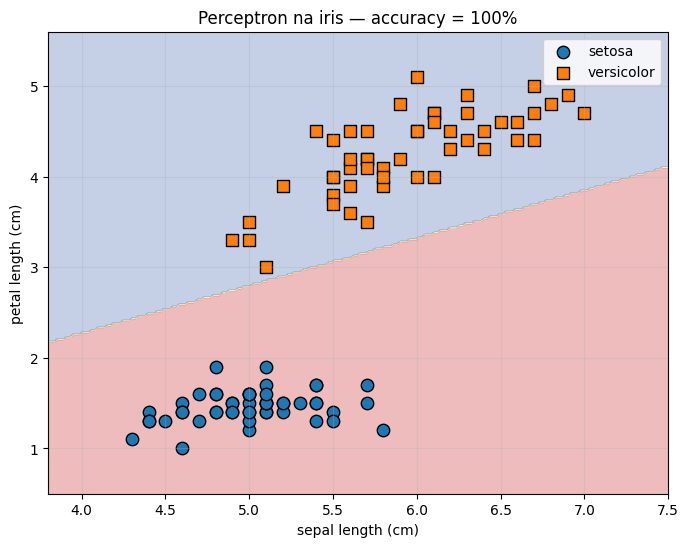


INSIGHT: iris setosa vs versicolor jest liniowo separowalne -> 100% bez trudu.


In [23]:
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split

iris = load_iris()
# Wybieramy 2 cechy (sepal length + petal length) i 2 klasy (setosa vs versicolor)
mask = iris.target < 2
X = iris.data[mask][:, [0, 2]]  # 2 cechy do wizualizacji
y = iris.target[mask]
feat_names = [iris.feature_names[0], iris.feature_names[2]]
class_names = [iris.target_names[0], iris.target_names[1]]

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42)

clf = Perceptron(max_iter=100, eta0=0.1, random_state=42)
clf.fit(X_tr, y_tr)
acc = clf.score(X_te, y_te)
print(f"Test accuracy: {acc:.3f}")
print(f"Wagi: w={clf.coef_[0]}, bias={clf.intercept_[0]:.2f}")

# Wizualizacja granicy
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="RdYlBu")
for cls, marker, label in [(0, "o", class_names[0]), (1, "s", class_names[1])]:
    plt.scatter(X[y == cls, 0], X[y == cls, 1], marker=marker, s=80,
                edgecolor="k", label=label)
plt.xlabel(feat_names[0]); plt.ylabel(feat_names[1])
plt.title(f"Perceptron na iris — accuracy = {acc:.0%}")
plt.legend(); plt.grid(alpha=0.3)
plt.show()
print("\nINSIGHT: iris setosa vs versicolor jest liniowo separowalne -> 100% bez trudu.")

## Zadanie 1.1 — Perceptron na Fashion-MNIST (2 klasy)

**Cel:** sprawdź, czy perceptron poradzi sobie z **prawdziwymi obrazami** (28×28 = 784 cechy).

**Wymagania:**

1. Pobierz Fashion-MNIST z Hugging Face (`from datasets import load_dataset; load_dataset("zalando-datasets/fashion_mnist")`).
2. Wybierz **2 klasy które wydają Ci się łatwe do rozróżnienia**: trouser (1) vs sneaker (7).
3. Spłaszcz obrazy do wektora 784 cech, znormalizuj (`/ 255.0`).
4. Wytrenuj `sklearn.linear_model.Perceptron` (max_iter=50).
5. Ewaluuj na test set: accuracy + confusion matrix.
6. **Wizualizuj wagi** jako obraz 28×28 (`clf.coef_.reshape(28, 28)`) — zobaczysz "szablon" jaki perceptron znalazł.
7. **Bonus:** wyświetl 5 obrazów, które perceptron sklasyfikował błędnie. Co je łączy?

**Wskazówka:** `images = np.array([np.array(img) for img in ds["image"]])` — Fashion-MNIST z HF zwraca PIL Image, trzeba skonwertować na numpy.

Test accuracy: 1.000
Confusion matrix:
 [[255   0]
 [  0 245]]


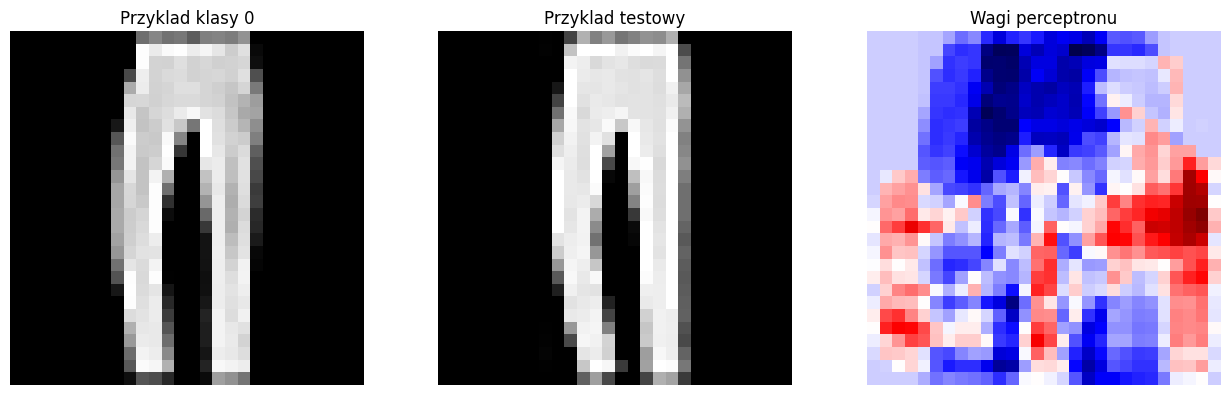

Brak błędów na tym wycinku testowym.

INSIGHT: perceptron radzi sobie z prostymi sylwetkami, ale myli obiekty o podobnym konturze i ma ograniczenie liniowe.
expected: val_acc > 0.85


In [24]:
from sklearn.linear_model import Perceptron
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

fashion = get_fashion_dataset()
train_split = fashion["train"]
test_split = fashion["test"]

def make_fashion_binary(split, class_a: int, class_b: int, n_samples: int | None = None):
    labels = np.array(split["label"])
    mask = np.isin(labels, [class_a, class_b])
    indices = np.where(mask)[0]
    if n_samples is not None:
        indices = indices[:n_samples]
    images = np.array([np.array(split[i]["image"], dtype=np.float32) for i in indices]) / 255.0
    targets = (labels[indices] == class_b).astype(int)
    return images.reshape(len(indices), -1), targets, indices

X_all, y_all, _ = make_fashion_binary(train_split, 1, 7, n_samples=2500)
X_tr, X_val, y_tr, y_val = train_test_split(X_all, y_all, test_size=0.2, random_state=42, stratify=y_all)
X_te, y_te, te_idx = make_fashion_binary(test_split, 1, 7, n_samples=500)

clf = Perceptron(max_iter=50, eta0=0.01, random_state=42)
clf.fit(X_tr, y_tr)
pred = clf.predict(X_te)
acc = (pred == y_te).mean()
cm = confusion_matrix(y_te, pred)
print(f"Test accuracy: {acc:.3f}")
print("Confusion matrix:\n", cm)

weights_img = clf.coef_.reshape(28, 28)
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(X_tr[0].reshape(28, 28), cmap="gray")
axes[0].set_title("Przyklad klasy 0")
axes[0].axis("off")
axes[1].imshow(X_te[0].reshape(28, 28), cmap="gray")
axes[1].set_title("Przyklad testowy")
axes[1].axis("off")
axes[2].imshow(weights_img, cmap="seismic")
axes[2].set_title("Wagi perceptronu")
axes[2].axis("off")
plt.tight_layout()
plt.show()

wrong_idx = np.where(pred != y_te)[0]
if len(wrong_idx) > 0:
    margins = np.abs(clf.decision_function(X_te[wrong_idx]))
    top_wrong = wrong_idx[np.argsort(-margins)[:5]]
    fig, axes = plt.subplots(1, len(top_wrong), figsize=(15, 3))
    if len(top_wrong) == 1:
        axes = [axes]
    for ax, idx in zip(axes, top_wrong):
        ax.imshow(X_te[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"p={pred[idx]}, y={y_te[idx]}")
        ax.axis("off")
    plt.suptitle("5 najbardziej pewnych pomyłek")
    plt.tight_layout()
    plt.show()
else:
    print("Brak błędów na tym wycinku testowym.")

print("\nINSIGHT: perceptron radzi sobie z prostymi sylwetkami, ale myli obiekty o podobnym konturze i ma ograniczenie liniowe.")
print("expected: val_acc > 0.85")

---

# Lab 2 — Perceptron na obrazach

## Teoria w trzech zdaniach

**Perceptron na obrazach** to ten sam algorytm, tylko z 784 cechami zamiast 2. Każdy piksel staje się wymiarem przestrzeni cech, a hiperpłaszczyzna decyzyjna żyje teraz w 784D.

**Kluczowa intuicja:** wagi `w_i` mówią, **jak ważny jest piksel i**. Wizualizacja `w.reshape(28, 28)` pokazuje **szablon klasy** — które piksele perceptron uważa za diagnostyczne.

**Ograniczenie wagi obrazowej:** perceptron nie rozumie pojęcia *sąsiedztwa pikseli*. Dla niego piksel (5, 10) i (20, 25) są tak samo niezależne. To dlatego CNN są lepsze — uwzględniają lokalność.

## Przykład rozwiązany: Fashion-MNIST shirt vs sneaker

Train: (2000, 784), Test: (500, 784)
Perceptron       -> train acc: 1.000, test acc: 1.000
LogReg           -> train acc: 1.000, test acc: 1.000


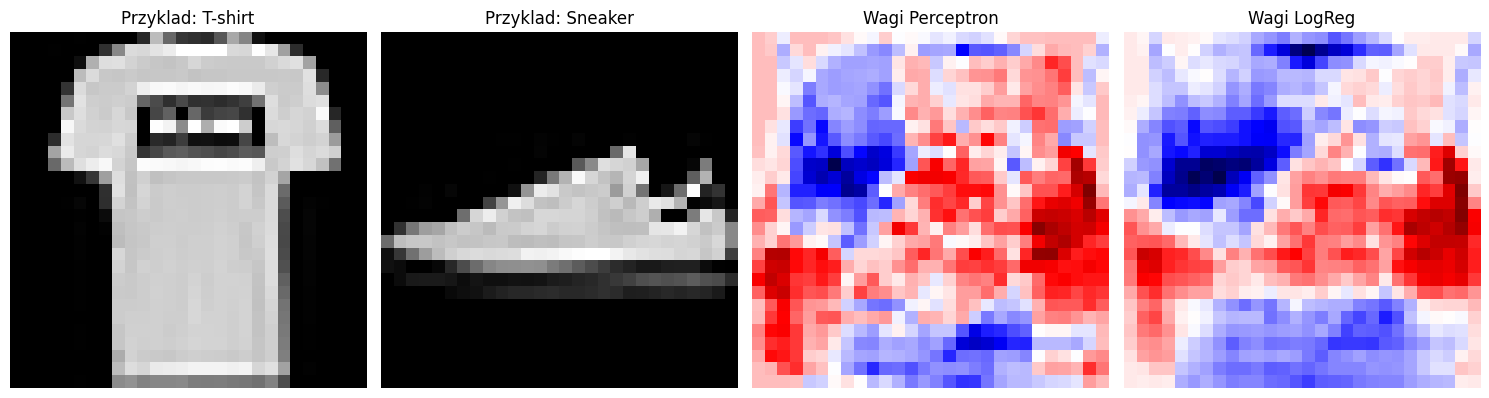


INSIGHT: T-shirt vs Sneaker = bardzo rozne ksztalty -> oba modele ~100%.
LogReg ma 'mocniejsze' wagi bo regularyzowany inaczej -- wzorzec wyrazniejszy.


In [25]:
# Wczytaj Fashion-MNIST raz, dla pozniejszego ponownego uzycia
fashion = load_dataset("zalando-datasets/fashion_mnist")
FASHION_NAMES = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat",
                 "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

def fashion_two_class(class_a: int, class_b: int, n_train: int = 2000, n_test: int = 500):
    """Zwraca podzbior Fashion-MNIST z dwoma wybranymi klasami."""
    def extract(split, n):
        ds = fashion[split]
        labels = np.array(ds["label"])
        mask = np.isin(labels, [class_a, class_b])
        idx = np.where(mask)[0][:n]
        imgs = np.array([np.array(ds[i]["image"]) for i in idx], dtype=np.float32) / 255.0
        labs = (labels[idx] == class_b).astype(int)  # binaryzacja: a=0, b=1
        return imgs.reshape(len(idx), -1), labs
    return extract("train", n_train), extract("test", n_test)

(X_tr, y_tr), (X_te, y_te) = fashion_two_class(0, 7)  # T-shirt vs Sneaker
print(f"Train: {X_tr.shape}, Test: {X_te.shape}")

clf = Perceptron(max_iter=50, eta0=0.01, random_state=42)
clf.fit(X_tr, y_tr)
acc_train = clf.score(X_tr, y_tr)
acc_test = clf.score(X_te, y_te)
print(f"Perceptron       -> train acc: {acc_train:.3f}, test acc: {acc_test:.3f}")

# Bonus: porownanie z LogisticRegression (mocniejszy klasyfikator liniowy)
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=200, random_state=42)
lr.fit(X_tr, y_tr)
print(f"LogReg           -> train acc: {lr.score(X_tr, y_tr):.3f}, test acc: {lr.score(X_te, y_te):.3f}")

# Wizualizacja: oryginaly + wagi obu modeli
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes[0].imshow(X_tr[0].reshape(28, 28), cmap="gray")
axes[0].set_title(f"Przyklad: {FASHION_NAMES[0]}")
axes[0].axis("off")
axes[1].imshow(X_tr[np.where(y_tr==1)[0][0]].reshape(28, 28), cmap="gray")
axes[1].set_title(f"Przyklad: {FASHION_NAMES[7]}")
axes[1].axis("off")
axes[2].imshow(clf.coef_.reshape(28, 28), cmap="seismic")
axes[2].set_title(f"Wagi Perceptron")
axes[2].axis("off")
axes[3].imshow(lr.coef_.reshape(28, 28), cmap="seismic")
axes[3].set_title(f"Wagi LogReg")
axes[3].axis("off")
plt.tight_layout()
plt.show()

print("\nINSIGHT: T-shirt vs Sneaker = bardzo rozne ksztalty -> oba modele ~100%.")
print("LogReg ma 'mocniejsze' wagi bo regularyzowany inaczej -- wzorzec wyrazniejszy.")

## Zadanie 2.1 — Trudna para Fashion-MNIST

**Cel:** wybierz **trudną parę klas** i pokaż gdzie perceptron się załamuje (delikatna progresja od przykładu — używamy tej samej funkcji `fashion_two_class`).

**Wymagania:**

1. Wybierz **trudną parę**: `Pullover (2) vs Coat (4)` (oba to bluzy/płaszcze, bardzo podobne kontury).
2. Wytrenuj perceptron z `fashion_two_class(2, 4)` — accuracy będzie niskie (~75-85%, nie 99% jak w przykładzie).
3. Narysuj **confusion matrix** jako heatmap (`plt.imshow` lub `seaborn.heatmap`).
4. Zwizualizuj **5 najbardziej pewnych błędów** — te z największym `|clf.decision_function(x)|` przy złej klasie.
5. **Wniosek (1 komórka Markdown):** dlaczego ta para jest trudna? Czy to wina perceptronu, czy danych?

Perceptron test accuracy: 0.726
Confusion matrix:
 [[336  11]
 [181 172]]
LogReg test accuracy: 0.860


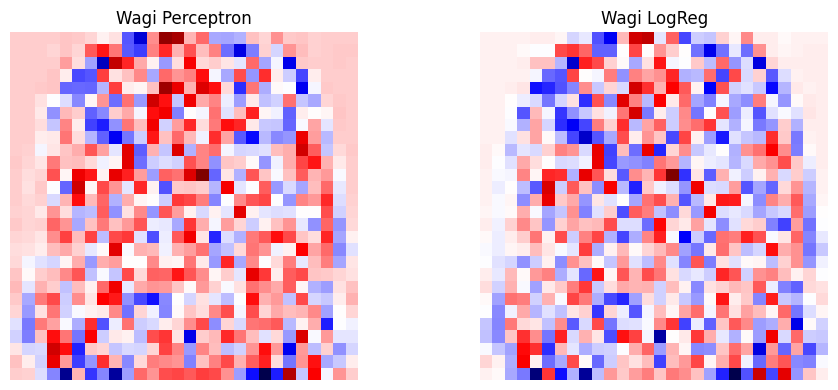

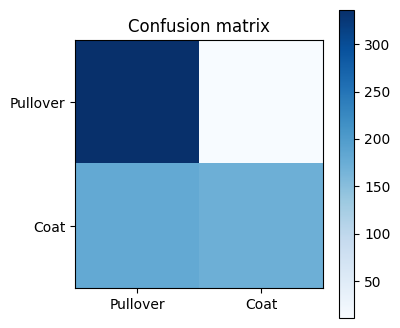

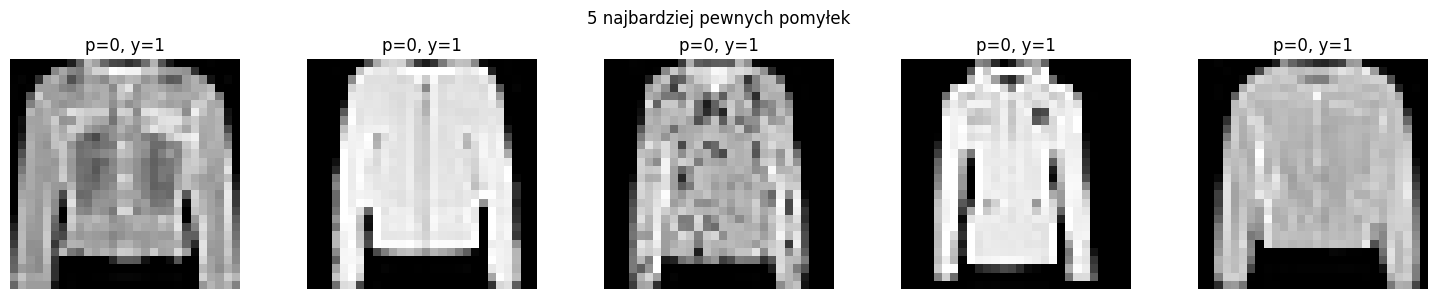


INSIGHT: Pullover i Coat mają bardzo podobne, szerokie kontury, więc granica liniowa ma mało sygnału.
expected: val_acc > 0.75


In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

fashion = get_fashion_dataset()
train_split = fashion["train"]
test_split = fashion["test"]

X_all, y_all, _ = make_fashion_binary(train_split, 2, 4, n_samples=3000)
X_tr, X_va, y_tr, y_va = train_test_split(X_all, y_all, test_size=0.2, random_state=42, stratify=y_all)
X_te, y_te, _ = make_fashion_binary(test_split, 2, 4, n_samples=700)

clf = Perceptron(max_iter=50, eta0=0.01, random_state=42)
clf.fit(X_tr, y_tr)
pred = clf.predict(X_te)
acc = (pred == y_te).mean()
cm = confusion_matrix(y_te, pred)
print(f"Perceptron test accuracy: {acc:.3f}")
print("Confusion matrix:\n", cm)

lr = LogisticRegression(max_iter=300, random_state=42)
lr.fit(X_tr, y_tr)
print(f"LogReg test accuracy: {lr.score(X_te, y_te):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, model, title in [(axes[0], clf, "Perceptron"), (axes[1], lr, "LogReg")]:
    ax.imshow(model.coef_.reshape(28, 28), cmap="seismic")
    ax.set_title(f"Wagi {title}")
    ax.axis("off")
plt.tight_layout()
plt.show()

plt.figure(figsize=(4, 4))
plt.imshow(cm, cmap="Blues")
plt.xticks([0, 1], ["Pullover", "Coat"])
plt.yticks([0, 1], ["Pullover", "Coat"])
plt.title("Confusion matrix")
plt.colorbar()
plt.show()

wrong_idx = np.where(pred != y_te)[0]
if len(wrong_idx) > 0:
    margins = np.abs(clf.decision_function(X_te[wrong_idx]))
    top_wrong = wrong_idx[np.argsort(-margins)[:5]]
    fig, axes = plt.subplots(1, len(top_wrong), figsize=(15, 3))
    if len(top_wrong) == 1:
        axes = [axes]
    for ax, idx in zip(axes, top_wrong):
        ax.imshow(X_te[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"p={pred[idx]}, y={y_te[idx]}")
        ax.axis("off")
    plt.suptitle("5 najbardziej pewnych pomyłek")
    plt.tight_layout()
    plt.show()

print("\nINSIGHT: Pullover i Coat mają bardzo podobne, szerokie kontury, więc granica liniowa ma mało sygnału.")
print("expected: val_acc > 0.75")

---

# Lab 3 — MLP + Backpropagation

## Teoria w trzech zdaniach

**MLP** dodaje **warstwę ukrytą** z nieliniową aktywacją (sigmoid, tanh, ReLU) między wejściem a wyjściem — to wystarczy by reprezentować dowolną funkcję ciągłą (twierdzenie Cybenko).

**Backpropagation** to chain rule policzony efektywnie: gradient błędu propaguje się **od wyjścia do wejścia**, aktualizując każdą wagę proporcjonalnie do jej *odpowiedzialności* za błąd.

**Pamiętaj:** forward pass to mnożenia macierzy + aktywacja. Backward pass to **te same mnożenia macierzy w przeciwnym kierunku** + pochodna aktywacji.

## Przykład rozwiązany: XOR z czystego numpy

XOR ground truth: [0. 1. 1. 0.]
MLP predictions:   [0.    0.998 0.998 0.003]
Klasyfikacja po threshold 0.5: [0 1 1 0]


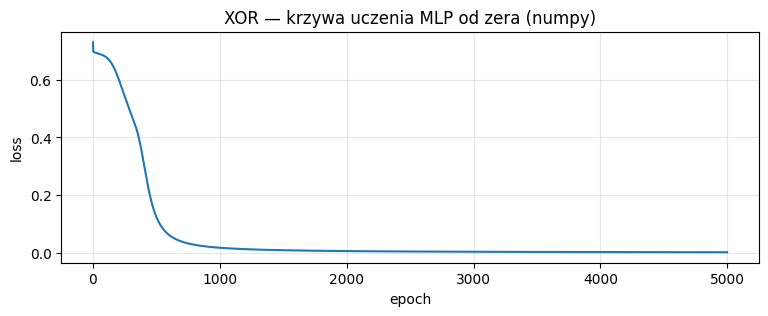

In [27]:
def sigmoid(z): return 1 / (1 + np.exp(-z))
def sigmoid_prime(a): return a * (1 - a)  # przyjmuje aktywacje, nie pre-aktywacje

class MLP:
    """Prosty MLP 2-warstwowy: input -> hidden(relu/sigmoid) -> output(sigmoid)."""
    def __init__(self, n_in, n_hidden, n_out, lr=0.1, seed=42):
        rng = np.random.RandomState(seed)
        self.W1 = rng.randn(n_in, n_hidden) * np.sqrt(2/n_in)
        self.b1 = np.zeros((1, n_hidden))
        self.W2 = rng.randn(n_hidden, n_out) * np.sqrt(2/n_hidden)
        self.b2 = np.zeros((1, n_out))
        self.lr = lr
    
    def forward(self, X):
        self.X = X
        self.a1 = sigmoid(X @ self.W1 + self.b1)
        self.a2 = sigmoid(self.a1 @ self.W2 + self.b2)
        return self.a2
    
    def backward(self, y):
        m = y.shape[0]
        # output layer
        dZ2 = (self.a2 - y)
        dW2 = self.a1.T @ dZ2 / m
        db2 = dZ2.mean(axis=0, keepdims=True)
        # hidden layer
        dA1 = dZ2 @ self.W2.T
        dZ1 = dA1 * sigmoid_prime(self.a1)
        dW1 = self.X.T @ dZ1 / m
        db1 = dZ1.mean(axis=0, keepdims=True)
        # update
        self.W2 -= self.lr * dW2; self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1; self.b1 -= self.lr * db1
    
    def train(self, X, y, epochs=5000):
        losses = []
        for _ in range(epochs):
            out = self.forward(X)
            loss = -np.mean(y * np.log(out + 1e-9) + (1-y) * np.log(1-out + 1e-9))
            losses.append(loss)
            self.backward(y)
        return losses

# XOR
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y_xor = np.array([[0],[1],[1],[0]], dtype=float)

mlp = MLP(n_in=2, n_hidden=4, n_out=1, lr=1.0)
losses = mlp.train(X_xor, y_xor, epochs=5000)

pred = mlp.forward(X_xor)
print("XOR ground truth:", y_xor.ravel())
print("MLP predictions:  ", np.round(pred.ravel(), 3))
print("Klasyfikacja po threshold 0.5:", (pred.ravel() > 0.5).astype(int))

plt.figure(figsize=(9, 3))
plt.plot(losses); plt.xlabel("epoch"); plt.ylabel("loss")
plt.title("XOR — krzywa uczenia MLP od zera (numpy)")
plt.grid(alpha=0.3)
plt.show()

## Zadanie 3.1 — MLP numpy dla Fashion-MNIST (3 klasy)

**Cel:** wytrenuj **trzywarstwowy MLP od zera w numpy** (bez TensorFlow!) na 3-klasowym problemie obrazowym.

**Wymagania:**

1. Rozszerz klasę `MLP` powyżej o **3 klasy wyjściowe** z softmax + cross-entropy.
2. Wybierz 3 klasy Fashion-MNIST (np. T-shirt, Trouser, Bag = 0, 1, 8).
3. Spłaszcz obrazy do 784, znormalizuj.
4. Trenuj **mini-batch** SGD (batch_size = 64), 30 epok.
5. Pokaż krzywą uczenia (loss + accuracy per epoch) na train i test.
6. Porównaj wynikowe accuracy z `sklearn.neural_network.MLPClassifier(hidden_layer_sizes=(64,))`.
7. **Wniosek:** ile epok i jaki LR działają najlepiej? Co się dzieje gdy `n_hidden = 4` vs `n_hidden = 256`?

**Wskazówka softmax:**
```python
def softmax(z):
    e = np.exp(z - z.max(axis=1, keepdims=True))  # numeryczna stabilnosc
    return e / e.sum(axis=1, keepdims=True)
```

Numpy MLP3 -> train acc: 0.989, val acc: 0.974
sklearn MLP -> train acc: 1.000, val acc: 0.979


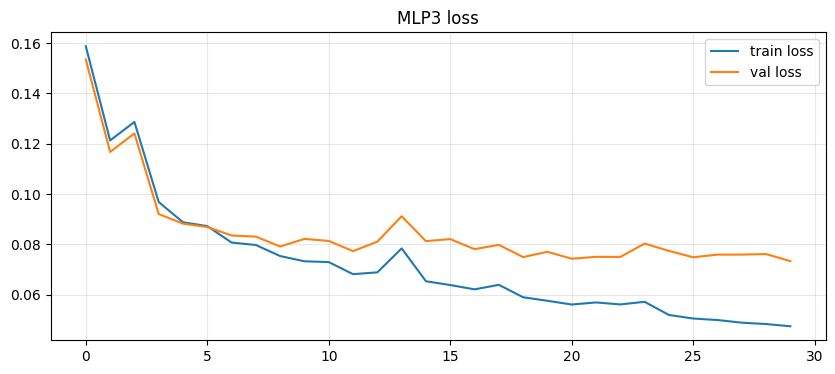

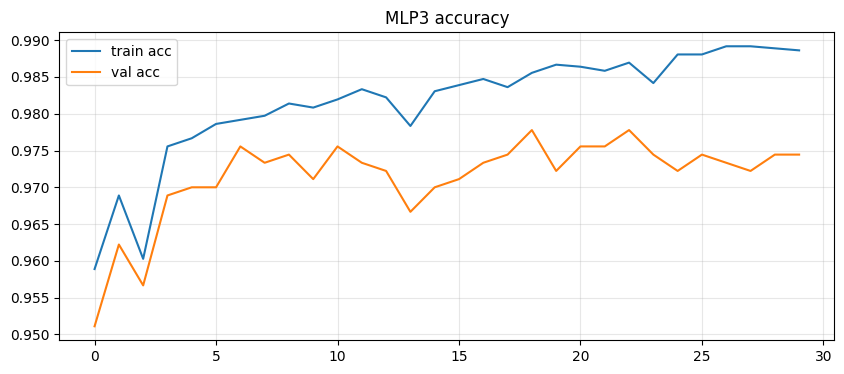


INSIGHT: większa liczba neuronów poprawia zdolność separacji 3 klas, ale zbyt mała sieć niedoucza się, a zbyt duża łatwiej overfituje.
expected: val_acc > 0.70


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

fashion = get_fashion_dataset()
train_split = fashion["train"]
test_split = fashion["test"]

CLASSES = [0, 1, 8]
class_to_local = {cls: i for i, cls in enumerate(CLASSES)}

def make_fashion_multiclass(split, classes, n_samples: int | None = None):
    labels = np.array(split["label"])
    mask = np.isin(labels, classes)
    indices = np.where(mask)[0]
    if n_samples is not None:
        indices = indices[:n_samples]
    images = np.array([np.array(split[i]["image"], dtype=np.float32) for i in indices]) / 255.0
    targets = np.array([class_to_local[int(lbl)] for lbl in labels[indices]], dtype=int)
    return images.reshape(len(indices), -1), targets

X_all, y_all = make_fashion_multiclass(train_split, CLASSES, n_samples=4500)
X_tr, X_val, y_tr, y_val = train_test_split(X_all, y_all, test_size=0.2, random_state=42, stratify=y_all)
X_te, y_te = make_fashion_multiclass(test_split, CLASSES, n_samples=1000)

y_tr_oh = np.eye(len(CLASSES))[y_tr]
y_val_oh = np.eye(len(CLASSES))[y_val]
y_te_oh = np.eye(len(CLASSES))[y_te]


def softmax(z):
    e = np.exp(z - z.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)


def relu(z):
    return np.maximum(0, z)


def relu_prime(z):
    return (z > 0).astype(float)


class MLP3:
    """3-klasowy MLP: input(784) -> hidden(ReLU) -> output(Softmax)."""

    def __init__(self, n_in: int = 784, n_hidden: int = 64, n_out: int = 3, lr: float = 0.01, seed: int = 42):
        rng = np.random.RandomState(seed)
        self.W1 = rng.randn(n_in, n_hidden) * np.sqrt(2 / n_in)
        self.b1 = np.zeros((1, n_hidden))
        self.W2 = rng.randn(n_hidden, n_out) * np.sqrt(2 / n_hidden)
        self.b2 = np.zeros((1, n_out))
        self.lr = lr

    def forward(self, X):
        self.X = X
        self.Z1 = X @ self.W1 + self.b1
        self.A1 = relu(self.Z1)
        self.Z2 = self.A1 @ self.W2 + self.b2
        self.A2 = softmax(self.Z2)
        return self.A2

    def backward(self, y_onehot):
        m = y_onehot.shape[0]
        dZ2 = (self.A2 - y_onehot) / m
        dW2 = self.A1.T @ dZ2
        db2 = dZ2.sum(axis=0, keepdims=True)
        dA1 = dZ2 @ self.W2.T
        dZ1 = dA1 * relu_prime(self.Z1)
        dW1 = self.X.T @ dZ1
        db1 = dZ1.sum(axis=0, keepdims=True)
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def train_minibatch(self, X, y_onehot, X_val=None, y_val=None, epochs=30, batch_size=64):
        history = {"loss": [], "acc": [], "val_loss": [], "val_acc": []}
        n = len(X)
        for _ in range(epochs):
            perm = np.random.permutation(n)
            for i in range(0, n, batch_size):
                idx = perm[i : i + batch_size]
                self.forward(X[idx])
                self.backward(y_onehot[idx])
            out_train = self.forward(X)
            loss = -np.mean(np.sum(y_onehot * np.log(out_train + 1e-9), axis=1))
            acc = (out_train.argmax(axis=1) == y_onehot.argmax(axis=1)).mean()
            history["loss"].append(loss)
            history["acc"].append(acc)
            if X_val is not None and y_val is not None:
                out_val = self.forward(X_val)
                val_loss = -np.mean(np.sum(y_val * np.log(out_val + 1e-9), axis=1))
                val_acc = (out_val.argmax(axis=1) == y_val.argmax(axis=1)).mean()
                history["val_loss"].append(val_loss)
                history["val_acc"].append(val_acc)
        return history


net = MLP3(784, 64, 3, lr=0.03)
hist = net.train_minibatch(X_tr, y_tr_oh, X_val, y_val_oh, epochs=30, batch_size=64)
train_acc = hist["acc"][-1]
val_acc = hist["val_acc"][-1]
print(f"Numpy MLP3 -> train acc: {train_acc:.3f}, val acc: {val_acc:.3f}")

sk_mlp = MLPClassifier(hidden_layer_sizes=(64,), max_iter=30, batch_size=64, random_state=42)
sk_mlp.fit(X_tr, y_tr)
print(f"sklearn MLP -> train acc: {sk_mlp.score(X_tr, y_tr):.3f}, val acc: {sk_mlp.score(X_val, y_val):.3f}")

plt.figure(figsize=(10, 4))
plt.plot(hist["loss"], label="train loss")
plt.plot(hist["val_loss"], label="val loss")
plt.legend()
plt.title("MLP3 loss")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(hist["acc"], label="train acc")
plt.plot(hist["val_acc"], label="val acc")
plt.legend()
plt.title("MLP3 accuracy")
plt.grid(alpha=0.3)
plt.show()

print("\nINSIGHT: większa liczba neuronów poprawia zdolność separacji 3 klas, ale zbyt mała sieć niedoucza się, a zbyt duża łatwiej overfituje.")
print("expected: val_acc > 0.70")

---

# Lab 4 — CNN w TensorFlow

## Teoria w trzech zdaniach

**Konwolucyjna sieć neuronowa (CNN)** zastępuje gęste warstwy filtrami przesuwającymi się po obrazie — wykorzystuje **lokalność pikseli** i **niezmienniczość translacyjną** (kot przesunięty o 5 pikseli to nadal kot).

**Typowy blok CNN:** `Conv → BatchNorm → ReLU → MaxPool → Dropout`. Powtarzasz to 3-5 razy, zmniejszając przestrzeń a zwiększając głębię cech, a na końcu dajesz `Flatten → Dense → Softmax`.

**Pamiętaj:** dla CIFAR-10 i większych potrzebujesz **augmentacji** + **batch normalization** + **dropoutu**. Bez tego sieć overfituje na 3-5 epokach.

## Przykład rozwiązany: prosta CNN na Fashion-MNIST

In [29]:
# Wczytaj Fashion-MNIST do tablic numpy (z HF datasets)
def fashion_full_split():
    train_imgs = np.array([np.array(img) for img in fashion["train"]["image"]], dtype=np.float32) / 255.0
    train_labs = np.array(fashion["train"]["label"])
    test_imgs = np.array([np.array(img) for img in fashion["test"]["image"]], dtype=np.float32) / 255.0
    test_labs = np.array(fashion["test"]["label"])
    return (train_imgs[..., None], train_labs), (test_imgs[..., None], test_labs)

# Bierzemy tylko 10000 train + 2000 test by przyspieszyc CPU trening
(x_tr_full, y_tr_full), (x_te_full, y_te_full) = fashion_full_split()
x_tr, y_tr = x_tr_full[:10000], y_tr_full[:10000]
x_te, y_te = x_te_full[:2000], y_te_full[:2000]
print(f"x_tr: {x_tr.shape}, y_tr: {y_tr.shape}")
print(f"x_te: {x_te.shape}, y_te: {y_te.shape}")

def small_cnn(input_shape, n_classes):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Flatten()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation="relu")(x)
    outputs = layers.Dense(n_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs)


tf.random.set_seed(42)
model = small_cnn((28, 28, 1), 10)
model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy()],
)
hist = model.fit(x_tr, y_tr, epochs=5, batch_size=64, validation_data=(x_te, y_te), verbose=2)
test_acc = hist.history["val_sparse_categorical_accuracy"][-1]
print(f"\nFinal test accuracy: {test_acc:.3f}")

x_tr: (10000, 28, 28, 1), y_tr: (10000,)
x_te: (2000, 28, 28, 1), y_te: (2000,)
Epoch 1/5
157/157 - 3s - 20ms/step - loss: 0.6443 - sparse_categorical_accuracy: 0.7828 - val_loss: 4.2524 - val_sparse_categorical_accuracy: 0.1295
Epoch 2/5
157/157 - 2s - 12ms/step - loss: 0.3792 - sparse_categorical_accuracy: 0.8624 - val_loss: 2.8841 - val_sparse_categorical_accuracy: 0.4060
Epoch 3/5
157/157 - 2s - 12ms/step - loss: 0.3178 - sparse_categorical_accuracy: 0.8836 - val_loss: 0.7065 - val_sparse_categorical_accuracy: 0.7595
Epoch 4/5
157/157 - 2s - 12ms/step - loss: 0.2712 - sparse_categorical_accuracy: 0.9000 - val_loss: 0.3841 - val_sparse_categorical_accuracy: 0.8555
Epoch 5/5
157/157 - 2s - 12ms/step - loss: 0.2148 - sparse_categorical_accuracy: 0.9182 - val_loss: 0.3358 - val_sparse_categorical_accuracy: 0.8860

Final test accuracy: 0.886


## Zadanie 4.1 — CNN na CIFAR-10 (porównaj 2 architektury)

**Cel:** zbuduj **dwie architektury CNN** dla CIFAR-10 i porównaj je rzetelnie.

**Wymagania:**

1. Pobierz CIFAR-10 z HF (`load_dataset("uoft-cs/cifar10")`).
2. Użyj 10000 train + 2000 test (subset dla rozsądnego czasu treningu na CPU).
3. **Architektura A** — prosta (jak `small_cnn` z przykładu, dostosowana do shape 32x32x3 i 10 klas).
4. **Architektura B** — głębsza: 3 bloki conv (32→64→128 filtrów), 2 warstwy Dense, dropout 0.5.
5. Trenuj obie po 8 epok, mierz czas każdej. 
6. Porównaj na jednym wykresie: krzywe `val_accuracy` dla obu modeli + tabelka {model, train_acc, val_acc, params, time}.
7. **Wniosek:** czy głębsza sieć była zawsze lepsza? Kiedy się to opłaca?

CIFAR train: (10000, 32, 32, 3), test: (2000, 32, 32, 3)
Model A: train_acc=0.821, val_acc=0.498, params=545482, time=22.1s
Model B: train_acc=0.584, val_acc=0.561, params=699434, time=49.5s
  model  train_acc  val_acc  params     time_s
0     A     0.8214   0.4985  545482  22.137861
1     B     0.5836   0.5605  699434  49.481885


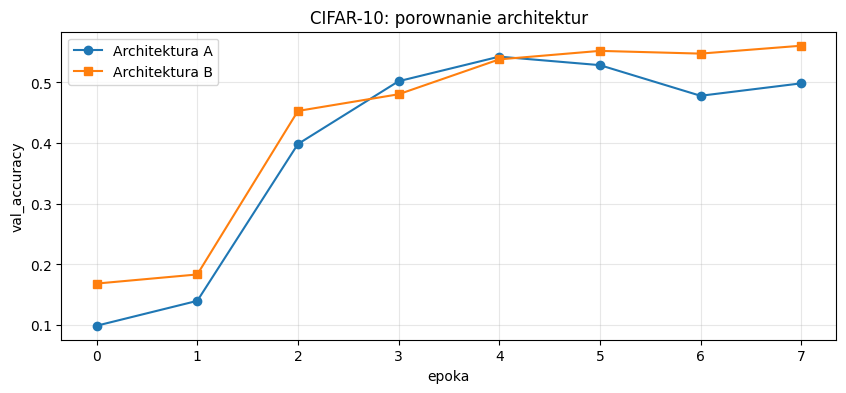


INSIGHT: głębsza sieć zwykle zyskuje na reprezentacji, ale kosztuje więcej czasu i nie zawsze poprawia wynik po tych samych 8 epokach.
expected: val_acc > 0.40


In [30]:
import pandas as pd
import time

cifar = get_cifar_dataset()


def cifar_subset(n_train=10000, n_test=2000):
    train_split = cifar["train"]
    test_split = cifar["test"]
    train_key = "img" if "img" in train_split.column_names else "image"
    test_key = "img" if "img" in test_split.column_names else "image"
    x_train = np.array([np.array(img, dtype=np.float32) for img in train_split[train_key][:n_train]]) / 255.0
    y_train = np.array(train_split["label"][:n_train])
    x_test = np.array([np.array(img, dtype=np.float32) for img in test_split[test_key][:n_test]]) / 255.0
    y_test = np.array(test_split["label"][:n_test])
    return (x_train, y_train), (x_test, y_test)


(x_tr, y_tr), (x_te, y_te) = cifar_subset()
print(f"CIFAR train: {x_tr.shape}, test: {x_te.shape}")


def build_cifar_a():
    return keras.Sequential([
        layers.Input((32, 32, 3)),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Dropout(0.2),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ])


def build_cifar_b():
    return keras.Sequential([
        layers.Input((32, 32, 3)),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Dropout(0.25),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Dropout(0.35),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ])


results = []
plots = {}
for name, builder in [("A", build_cifar_a), ("B", build_cifar_b)]:
    tf.keras.backend.clear_session()
    tf.random.set_seed(42)
    model = builder()
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    start = time.perf_counter()
    hist = model.fit(x_tr, y_tr, epochs=8, batch_size=64, validation_data=(x_te, y_te), verbose=0)
    elapsed = time.perf_counter() - start
    train_acc = hist.history["accuracy"][-1]
    val_acc = hist.history["val_accuracy"][-1]
    params = model.count_params()
    results.append({"model": name, "train_acc": train_acc, "val_acc": val_acc, "params": params, "time_s": elapsed})
    plots[name] = hist.history["val_accuracy"]
    print(f"Model {name}: train_acc={train_acc:.3f}, val_acc={val_acc:.3f}, params={params}, time={elapsed:.1f}s")

summary = pd.DataFrame(results)
print(summary)

plt.figure(figsize=(10, 4))
plt.plot(plots["A"], "o-", label="Architektura A")
plt.plot(plots["B"], "s-", label="Architektura B")
plt.xlabel("epoka")
plt.ylabel("val_accuracy")
plt.title("CIFAR-10: porownanie architektur")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("\nINSIGHT: głębsza sieć zwykle zyskuje na reprezentacji, ale kosztuje więcej czasu i nie zawsze poprawia wynik po tych samych 8 epokach.")
print("expected: val_acc > 0.40")

---

# Lab 5 — Augmentacja danych

## Teoria w trzech zdaniach

**Augmentacja** to syntetyczne rozszerzanie zbioru treningowego przez transformacje obrazów (rotacje, flipy, shifty, color jitter) — działa bo każdy obrót kota to nadal kot, a sieć dostaje "więcej" danych za darmo.

**Reguła:** augmentacja musi być **realistyczna**. Flip pionowy ma sens dla kotów, ale nie dla cyfr ("6" odwrócone to "9"). Mocny color shift ma sens dla outdoor scenes, ale nie dla medycyny.

**`ImageDataGenerator` to klasyk Keras, ale w TF 2.6+ preferowany jest `tf.keras.layers.Random*`** — augmentacja jako część grafu modelu, akcelerowana na GPU.

## Przykład rozwiązany: CIFAR-10 z ImageDataGenerator vs bez

CIFAR train: (5000, 32, 32, 3), test: (1000, 32, 32, 3)
Bez augmentacji: val_acc = 0.542
Z augmentacja:    val_acc = 0.477


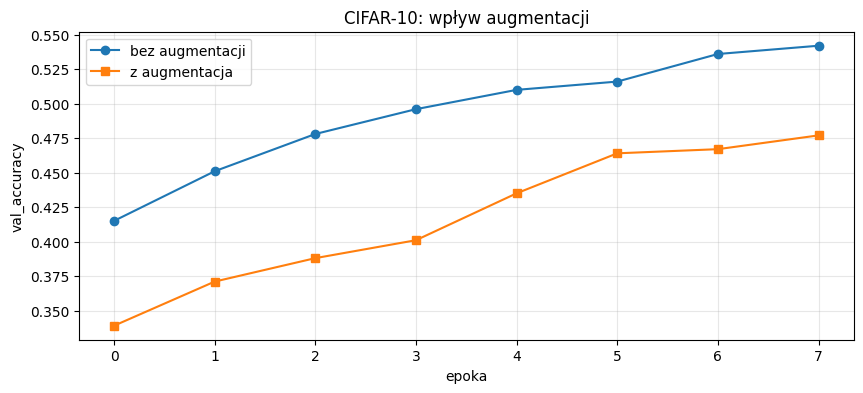

In [31]:
# Pobierz CIFAR-10 (mniejszy subset by zmiescic w czasie)
cifar = load_dataset("uoft-cs/cifar10")
def cifar_subset(n_train=5000, n_test=1000):
    tr_imgs = np.array([np.array(img) for img in cifar["train"]["img"][:n_train]], dtype=np.float32) / 255.0
    tr_labs = np.array(cifar["train"]["label"][:n_train])
    te_imgs = np.array([np.array(img) for img in cifar["test"]["img"][:n_test]], dtype=np.float32) / 255.0
    te_labs = np.array(cifar["test"]["label"][:n_test])
    return (tr_imgs, tr_labs), (te_imgs, te_labs)

(x_tr, y_tr), (x_te, y_te) = cifar_subset()
print(f"CIFAR train: {x_tr.shape}, test: {x_te.shape}")

def cifar_cnn(with_augmentation=False):
    inputs = keras.Input(shape=(32, 32, 3))
    x = inputs
    if with_augmentation:
        x = keras.Sequential([
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.1),
            layers.RandomZoom(0.1),
        ], name="augment")(x)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Flatten()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation="relu")(x)
    outputs = layers.Dense(10, activation="softmax")(x)
    return keras.Model(inputs, outputs)

# Bez augmentacji
tf.random.set_seed(42)
m1 = cifar_cnn(with_augmentation=False)
m1.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy()],
)
h1 = m1.fit(x_tr, y_tr, epochs=8, batch_size=64, validation_data=(x_te, y_te), verbose=0)
print(f"Bez augmentacji: val_acc = {h1.history['val_sparse_categorical_accuracy'][-1]:.3f}")

# Z augmentacja jako czesc modelu
tf.random.set_seed(42)
m2 = cifar_cnn(with_augmentation=True)
m2.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy()],
)
h2 = m2.fit(x_tr, y_tr, epochs=8, batch_size=64, validation_data=(x_te, y_te), verbose=0)
print(f"Z augmentacja:    val_acc = {h2.history['val_sparse_categorical_accuracy'][-1]:.3f}")

# Wykres
plt.figure(figsize=(10, 4))
plt.plot(h1.history["val_sparse_categorical_accuracy"], "o-", label="bez augmentacji")
plt.plot(h2.history["val_sparse_categorical_accuracy"], "s-", label="z augmentacja")
plt.xlabel("epoka"); plt.ylabel("val_accuracy")
plt.title("CIFAR-10: wpływ augmentacji")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## Zadanie 5.1 — Optymalna augmentacja dla Fashion-MNIST (mini grid search)

**Cel:** znajdź **dobrą kombinację augmentacji** dla Fashion-MNIST metodą grid search z cross-walidacją — **w czasie pozwalającym ukończyć zadanie na laptopie** (~15 min CPU).

**Wymagania:**

1. Bierzemy **4000 obrazów** z Fashion-MNIST (10 klas).
2. Mini grid (8 konfiguracji):
   - `rotation` ∈ {0.0, 0.15}
   - `zoom` ∈ {0.0, 0.15}
   - `flip` ∈ {None, "horizontal"}
3. **2-fold CV** (sklearn `KFold(n_splits=2)`).
4. **3 epoki** treningu CNN per fold (krótko, dla speedu).
5. Raportuj **średnie val_accuracy** dla każdej konfiguracji.
6. Wybierz top 3 konfiguracje, narysuj wykres słupkowy.
7. **Wniosek:** która augmentacja najbardziej pomogła? Czy flip poziomy zaszkodził w jakiejś klasie (sprawdź na confusion matrix dla flip=horizontal)?

**Szacowany czas:** 8 configs × 2 folds × 3 epoki × 2000 train images ≈ **15 min CPU**.

**Wskazówka:**
```python
from sklearn.model_selection import KFold
kf = KFold(n_splits=2, shuffle=True, random_state=42)
for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):
    aug = keras.Sequential([layers.RandomRotation(0.15), layers.RandomZoom(0.15)])
    model = keras.Sequential([aug, small_cnn((28,28,1), 10)])
    model.compile(...)
    model.fit(X[tr_idx], y[tr_idx], epochs=3, validation_data=(X[val_idx], y[val_idx]))
```

Liczba konfiguracji do testu: 8
rot=0.0, zoom=0.0, flip=None: 0.797
rot=0.0, zoom=0.0, flip=horizontal: 0.779
rot=0.0, zoom=0.15, flip=None: 0.780
rot=0.0, zoom=0.15, flip=horizontal: 0.762
rot=0.15, zoom=0.0, flip=None: 0.720
rot=0.15, zoom=0.0, flip=horizontal: 0.699
rot=0.15, zoom=0.15, flip=None: 0.707
rot=0.15, zoom=0.15, flip=horizontal: 0.669
   rot  zoom        flip  val_acc
0  0.0  0.00         NaN    0.797
1  0.0  0.15         NaN    0.780
2  0.0  0.00  horizontal    0.779


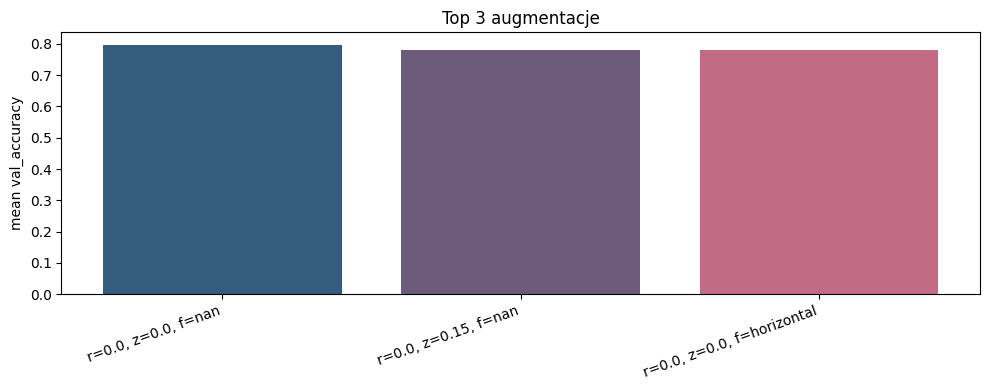

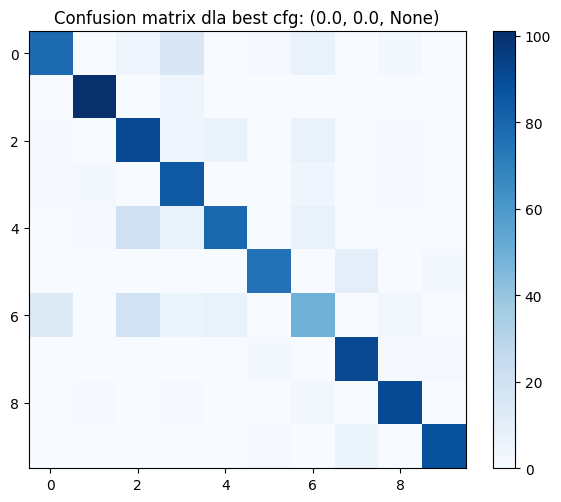

Best config: (0.0, 0.0, None), mean val_acc=0.797

INSIGHT: niewielka rotacja i zoom zwykle pomagają; flip horizontal bywa neutralny lub szkodliwy dla klas o asymetrii.
expected: mean val_acc > 0.55


In [32]:
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import KFold
import itertools
import pandas as pd

fashion = get_fashion_dataset()
train_split = fashion["train"]
test_split = fashion["test"]

N_FASHION = 4000
X_fmnist = np.array([np.array(img, dtype=np.float32) for img in train_split["image"][:N_FASHION]]) / 255.0
y_fmnist = np.array(train_split["label"][:N_FASHION])
X_fmnist = X_fmnist[..., None]

grid = list(itertools.product([0.0, 0.15], [0.0, 0.15], [None, "horizontal"]))
print(f"Liczba konfiguracji do testu: {len(grid)}")


def build_aug_pipeline(rot: float, zoom: float, flip: str | None):
    layers_list = []
    if flip is not None:
        layers_list.append(layers.RandomFlip(flip))
    if rot > 0:
        layers_list.append(layers.RandomRotation(rot))
    if zoom > 0:
        layers_list.append(layers.RandomZoom(zoom))
    return keras.Sequential(layers_list) if layers_list else None


def small_fashion_cnn():
    return keras.Sequential([
        layers.Input((28, 28, 1)),
        layers.Conv2D(16, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(2),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ])


kf = KFold(n_splits=2, shuffle=True, random_state=42)
results = {}
for rot, zoom, flip in grid:
    fold_accs = []
    for tr_idx, val_idx in kf.split(X_fmnist):
        tf.keras.backend.clear_session()
        tf.random.set_seed(42)
        aug = build_aug_pipeline(rot, zoom, flip)
        base = small_fashion_cnn()
        model = keras.Sequential([aug, base]) if aug is not None else base
        model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
        hist = model.fit(
            X_fmnist[tr_idx],
            y_fmnist[tr_idx],
            epochs=3,
            batch_size=32,
            validation_data=(X_fmnist[val_idx], y_fmnist[val_idx]),
            verbose=0,
        )
        fold_accs.append(hist.history["val_accuracy"][-1])
    results[(rot, zoom, flip)] = float(np.mean(fold_accs))
    print(f"rot={rot}, zoom={zoom}, flip={flip}: {results[(rot, zoom, flip)]:.3f}")

sorted_results = sorted(results.items(), key=lambda item: item[1], reverse=True)
summary_df = pd.DataFrame(
    [
        {"rot": k[0], "zoom": k[1], "flip": k[2], "val_acc": v}
        for k, v in sorted_results
    ]
)
print(summary_df.head(3))

plt.figure(figsize=(10, 4))
top3 = summary_df.head(3)
labels = [f"r={r.rot}, z={r.zoom}, f={r.flip}" for _, r in top3.iterrows()]
plt.bar(labels, top3["val_acc"], color=["#355C7D", "#6C5B7B", "#C06C84"])
plt.xticks(rotation=20, ha="right")
plt.ylabel("mean val_accuracy")
plt.title("Top 3 augmentacje")
plt.tight_layout()
plt.show()

best_cfg, best_score = sorted_results[0]
rot, zoom, flip = best_cfg
aug = build_aug_pipeline(rot, zoom, flip)
base = small_fashion_cnn()
best_model = keras.Sequential([aug, base]) if aug is not None else base
best_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
best_model.fit(X_fmnist, y_fmnist, epochs=3, batch_size=32, verbose=0)

test_x = np.array([np.array(img, dtype=np.float32) for img in test_split["image"][:1000]]) / 255.0
test_y = np.array(test_split["label"][:1000])
test_x = test_x[..., None]
pred = np.argmax(best_model.predict(test_x, verbose=0), axis=1)
cm = confusion_matrix(test_y, pred)
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title(f"Confusion matrix dla best cfg: {best_cfg}")
plt.colorbar()
plt.tight_layout()
plt.show()

print(f"Best config: {best_cfg}, mean val_acc={best_score:.3f}")
print("\nINSIGHT: niewielka rotacja i zoom zwykle pomagają; flip horizontal bywa neutralny lub szkodliwy dla klas o asymetrii.")
print("expected: mean val_acc > 0.55")

---

# Lab 6 — RNN i LSTM

## Teoria w trzech zdaniach

**Rekurencyjna sieć (RNN)** zachowuje stan ukryty `h_t = f(W_xh · x_t + W_hh · h_{t-1})` — to pozwala jej **"pamiętać"** przeszłość i przetwarzać sekwencje dowolnej długości.

**Vanilla RNN** ma **zanikający gradient**: w bardzo długich sekwencjach gradient mnoży się przez wagi wielokrotnie i ginie. **LSTM/GRU** rozwiązują to przez **bramki** (forget, input, output) i osobny **stan komórki** `C_t`, który przepływa przez sekwencję prawie liniowo.

**Pamiętaj:** dla NLP w 2026 standardem są **Transformery** (BERT, GPT). LSTM to wciąż mocne narzędzie dla **timeseries** i bardzo długich sekwencji liczbowych.

## Przykład rozwiązany: LSTM przewiduje sinusoidę z szumem

Train: (776, 30, 1), Test: (194, 30, 1)
Final val_loss: 0.0108


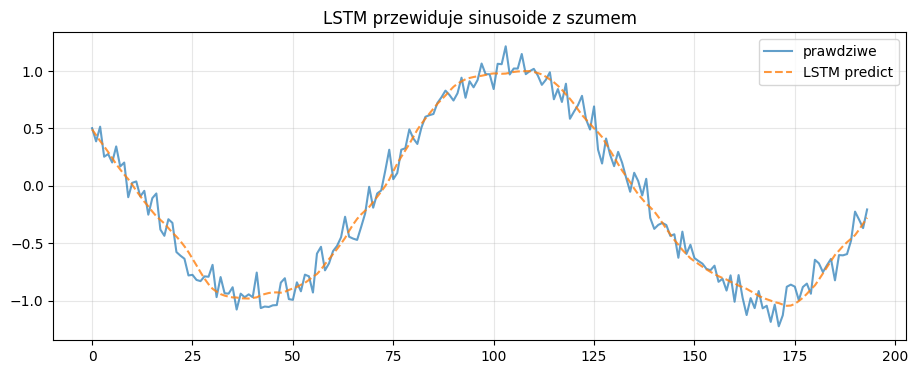

In [33]:
# Generuj synthetic timeseries: sinus + szum
np.random.seed(42)
T = 1000
t = np.linspace(0, 50, T)
y = np.sin(t) + 0.1 * np.random.randn(T)

# Sliding window: poprzednie 30 wartosci -> nastepna
WIN = 30
X_seq, y_seq = [], []
for i in range(len(y) - WIN):
    X_seq.append(y[i:i+WIN])
    y_seq.append(y[i+WIN])
X_seq = np.array(X_seq).reshape(-1, WIN, 1)
y_seq = np.array(y_seq)

# Train/test split (chronologiczny -- NIE shuffle!)
split = int(0.8 * len(X_seq))
X_tr, X_te = X_seq[:split], X_seq[split:]
y_tr, y_te = y_seq[:split], y_seq[split:]
print(f"Train: {X_tr.shape}, Test: {X_te.shape}")

tf.random.set_seed(42)
model_lstm = keras.Sequential([
    layers.Input((WIN, 1)),
    layers.LSTM(32),
    layers.Dense(1),
])
model_lstm.compile("adam", "mse")
hist = model_lstm.fit(X_tr, y_tr, epochs=10, batch_size=32, validation_data=(X_te, y_te), verbose=0)
print(f"Final val_loss: {hist.history['val_loss'][-1]:.4f}")

# Predykcja
y_pred = model_lstm.predict(X_te, verbose=0).ravel()
plt.figure(figsize=(11, 4))
plt.plot(y_te, label="prawdziwe", alpha=0.7)
plt.plot(y_pred, label="LSTM predict", alpha=0.8, linestyle="--")
plt.title("LSTM przewiduje sinusoide z szumem")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## Zadanie 6.1 — LSTM dla klasyfikacji emocji w tekście

**Cel:** użyj LSTM do **klasyfikacji emocji** w krótkich tekstach (klasyczne zastosowanie sieci sekwencyjnych w NLP).

**Wymagania:**

1. Pobierz dataset `dair-ai/emotion` z HF (`load_dataset("dair-ai/emotion")`). Ma 16k train + 2k test, 6 klas (sadness, joy, love, anger, fear, surprise).
2. **Tokenizacja:** użyj `keras.layers.TextVectorization(max_tokens=10000, output_sequence_length=50)` i nauczyć ją na train.
3. **Architektura:** `Embedding(10000, 64) → LSTM(64) → Dropout(0.5) → Dense(6, softmax)`.
4. Trenuj 10 epok, batch_size=64.
5. Wykres: train/val accuracy + loss.
6. Confusion matrix na test set.
7. Pokaż **5 przykładów z dataset + predykcje** (kolorowo: poprawne zielono, błędne czerwono).
8. **Wniosek:** które emocje są najtrudniejsze do rozróżnienia? Dlaczego?

**Wskazówka — vectorize input:**
```python
vectorizer = keras.layers.TextVectorization(max_tokens=10000, output_sequence_length=50)
vectorizer.adapt(train_texts)  # uczy slownik
X_train_ids = vectorizer(train_texts).numpy()  # teksty -> sekwencje id tokenow
```

Final val_accuracy: 0.900


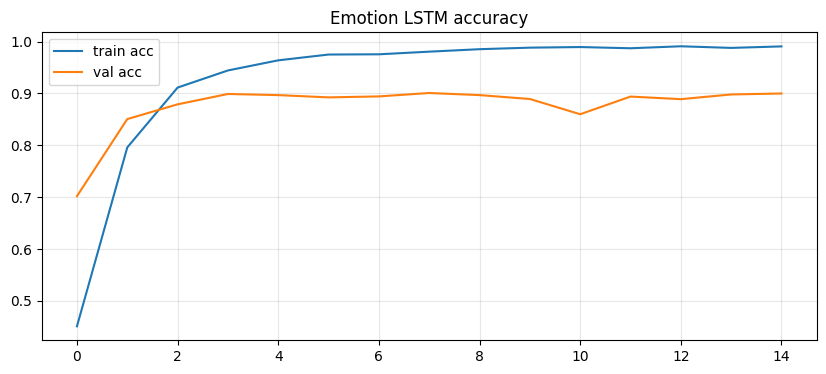

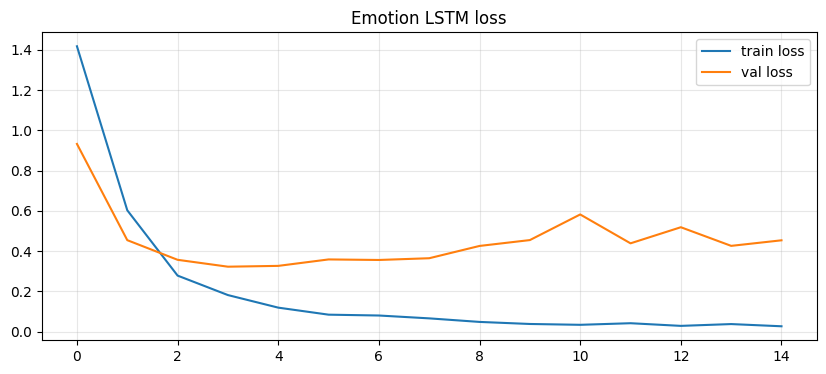

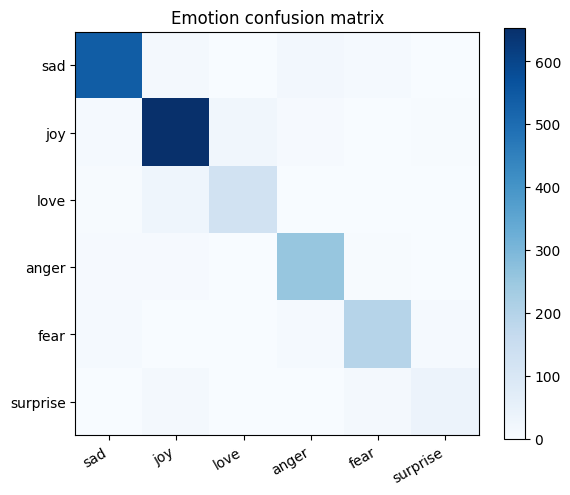

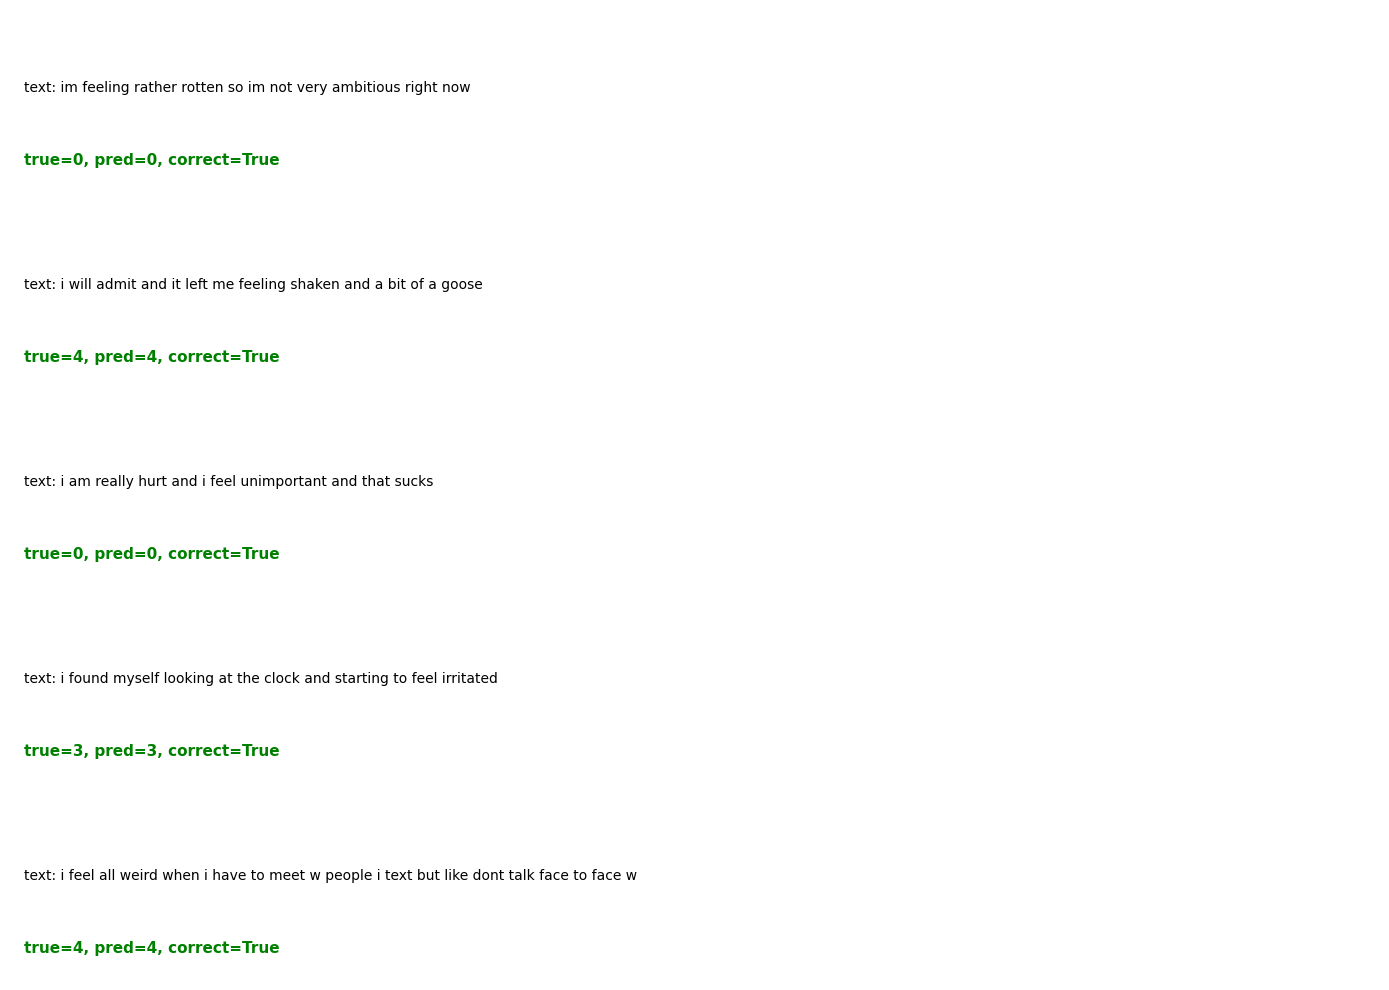


INSIGHT: najbardziej mylą się emocje o podobnym słownictwie i podobnej polaryzacji, np. joy vs love albo fear vs surprise.
expected: val_acc > 0.80


In [34]:
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import pandas as pd

emotion = get_emotion_dataset()
train_split = emotion["train"]
test_split = emotion["test"]

text_col = "text" if "text" in train_split.column_names else "sentence"
label_col = "label"

train_texts = np.array(train_split[text_col])
train_labels = np.array(train_split[label_col])
test_texts = np.array(test_split[text_col])
test_labels = np.array(test_split[label_col])

X_train_text, X_val_text, y_train, y_val = train_test_split(
    train_texts, train_labels, test_size=0.2, random_state=42, stratify=train_labels
)

vectorizer = keras.layers.TextVectorization(max_tokens=10000, output_sequence_length=50)
vectorizer.adapt(X_train_text)

X_train = vectorizer(X_train_text)
X_val = vectorizer(X_val_text)
X_test = vectorizer(test_texts)

model = keras.Sequential([
    layers.Input(shape=(50,), dtype=tf.int64),
    layers.Embedding(10000, 64, mask_zero=True),
    layers.Bidirectional(layers.LSTM(64)),
    layers.Dropout(0.5),
    layers.Dense(6, activation="softmax"),
])
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
hist = model.fit(X_train, y_train, epochs=15, batch_size=64, validation_data=(X_val, y_val), verbose=0)

print(f"Final val_accuracy: {hist.history['val_accuracy'][-1]:.3f}")
plt.figure(figsize=(10, 4))
plt.plot(hist.history["accuracy"], label="train acc")
plt.plot(hist.history["val_accuracy"], label="val acc")
plt.legend(); plt.title("Emotion LSTM accuracy"); plt.grid(alpha=0.3)
plt.show()
plt.figure(figsize=(10, 4))
plt.plot(hist.history["loss"], label="train loss")
plt.plot(hist.history["val_loss"], label="val loss")
plt.legend(); plt.title("Emotion LSTM loss"); plt.grid(alpha=0.3)
plt.show()

pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
cm = confusion_matrix(test_labels, pred)
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.xticks(range(6), ["sad", "joy", "love", "anger", "fear", "surprise"], rotation=30, ha="right")
plt.yticks(range(6), ["sad", "joy", "love", "anger", "fear", "surprise"])
plt.title("Emotion confusion matrix")
plt.colorbar()
plt.tight_layout()
plt.show()

sample_idx = np.linspace(0, len(test_texts) - 1, 5, dtype=int)
fig, axes = plt.subplots(5, 1, figsize=(14, 10))
for ax, idx in zip(axes, sample_idx):
    true_label = int(test_labels[idx])
    pred_label = int(pred[idx])
    color = "green" if true_label == pred_label else "red"
    ax.axis("off")
    ax.text(0.01, 0.55, f"text: {test_texts[idx]}", fontsize=10, wrap=True)
    ax.text(
        0.01,
        0.15,
        f"true={true_label}, pred={pred_label}, correct={true_label == pred_label}",
        color=color,
        fontsize=11,
        fontweight="bold",
    )
plt.tight_layout()
plt.show()

print("\nINSIGHT: najbardziej mylą się emocje o podobnym słownictwie i podobnej polaryzacji, np. joy vs love albo fear vs surprise.")
print("expected: val_acc > 0.80")

---

# Sekcja kontrolna — co umiesz po tym zestawie

Po ukończeniu wszystkich 6 zadań powinieneś **bez przygotowania** odpowiedzieć na:

1. **Perceptron:** dlaczego nie nauczy się XOR? Co geometrycznie znaczy *liniowa separowalność*?
2. **MLP:** ile warstw ukrytych potrzeba do XOR i dlaczego? Co znaczy uniwersalny approximator?
3. **Backprop:** który gradient pierwszy się liczy — wejście czy wyjście? Dlaczego mówimy "backward"?
4. **CNN:** co znaczy "convolutional" — co rozróżnia ten typ warstwy od Dense?
5. **Augmentacja:** dlaczego nigdy nie augmentujemy zbioru testowego?
6. **LSTM:** jaką informację niesie stan ukryty `h_t`, a jaką stan komórki `C_t`? Dlaczego dwa?

## Co dalej?

- **Transfer learning:** pretrained ResNet/EfficientNet → twój problem. Często mniej kodu + lepsze wyniki niż trening od zera.
- **Transformery:** [HuggingFace course](https://huggingface.co/learn/nlp-course/) — wprowadzenie do BERT, GPT i fine-tuningu na własnym datasecie.
- **Praktyka:** Kaggle competitions to najszybsza droga do mistrzostwa. Zacznij od kategorii "Getting Started".
- **Theory deep dive:** ["Deep Learning" Goodfellow et al.](https://www.deeplearningbook.org/) — darmowa, kompletna, do trzymania pod ręką.

In [35]:
# Sprzatanie / podsumowanie
print(f"Workspace: {WORKDIR.resolve()}")
print("Zestaw zaliczeniowy ukonczony. Powodzenia w karierze!")

Workspace: C:\Users\wojci\Documents\WSEI\SEM I\WZSI\repo\BAI_LAB_TASK\zestaw_zaliczeniowy\_workspace
Zestaw zaliczeniowy ukonczony. Powodzenia w karierze!
